# Energy Communities in AMP: Data Understanding 

This notebook covers the **Data Understanding** phase of the CRISP-DM methodology applied to energy consumption and energy communities data for the 17 municipalities of the Área Metropolitana do Porto (AMP).

The two datasets used are:

**Consumos faturados**: monthly billed electricity consumption per parish, split by voltage level, covering around 10 years

**Comunidades de energia**: registry of ACC (Autoconsumo Coletivo) and CER (Comunidade de Energia Renovável) communities per parish and date

The goal of this phase is to assess data quality, understand temporal and spatial patterns, and identify any issues that must be addressed before modelling.

## 1.Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import kruskal, mannwhitneyu
from statsmodels.tsa.stattools import acf, pacf, adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import os

#Directories
output_dir = 'DU_output'
os.makedirs(output_dir, exist_ok=True)


# Plotting configurations
PALETTE, ACCENT, ACCENT2, ACCENT3 = "viridis", "#2E86AB", "#E84855", "#F6AE2D"
BG = "#F8F9FA"

plt.rcParams.update({
    "figure.facecolor": BG, "axes.facecolor": BG,
    "figure.dpi": 110, "axes.titlesize": 13, "axes.labelsize": 10
})
sns.set_theme(style="whitegrid", palette=PALETTE)

# AMP municipalities 
AMP_MUNICIPALITIES = [
    "Porto", "Vila Nova de Gaia", "Matosinhos", "Maia", "Gondomar", "Valongo",
    "Póvoa de Varzim", "Vila do Conde", "Trofa", "Santo Tirso", "Espinho",
    "Santa Maria da Feira", "Oliveira de Azeméis", "São João da Madeira",
    "Arouca", "Vale de Cambra", "Paredes"
]

print(f"AMP: {len(AMP_MUNICIPALITIES)} municipalities")

AMP: 17 municipalities


## 2.Load & Filter Data

In [2]:
# Load datasets
consumos_raw = pd.read_csv(
    "../input/3-consumos-faturados-por-municipio-ultimos-10-anos.csv",
    sep=";", encoding="utf-8", on_bad_lines="skip",
    dtype={"coddistritoconcelho": str, "DistrictMunicipalityParishCode": str}
)

comunidades_raw = pd.read_csv(
    "../input/comunidades-de-energia.csv",
    sep=";", encoding="utf-8", on_bad_lines="skip",
    dtype={"Parish Code": str}
)

# Convert to numeric
consumos_raw["Energia Ativa"] = pd.to_numeric(consumos_raw["Energia Ativa"], errors="coerce")
consumos_raw[["Year", "Month"]] = consumos_raw[["Year", "Month"]].apply(
    lambda x: pd.to_numeric(x, errors="coerce")
)
comunidades_raw[" ACC/CER Type Count "] = pd.to_numeric(
    comunidades_raw[" ACC/CER Type Count "], errors="coerce"
)

# Parse dates
consumos_raw["Date"] = pd.to_datetime(consumos_raw["Date"], format="%Y-%m", errors="coerce")
comunidades_raw["Date"] = pd.to_datetime(comunidades_raw["Date"], format="%Y-%m", errors="coerce")
comunidades_raw.rename(columns={" ACC/CER Type Count ": "ACC_CER_Count"}, inplace=True)

# Filter to AMP
consumos = consumos_raw[consumos_raw["Municipality"].isin(AMP_MUNICIPALITIES)].copy()
comunidades = comunidades_raw[comunidades_raw["Municipality"].isin(AMP_MUNICIPALITIES)].copy()

print(f"Datasets filtered to AMP:")
print(f"consumos: {len(consumos):,} rows")
print(f"comunidades: {len(comunidades):,} rows")
print(f"AMP municipalities (consumos): {consumos['Municipality'].nunique()}")
print(f"AMP municipalities (comunidades): {comunidades['Municipality'].nunique()}")

Datasets filtered to AMP:
consumos: 19,165 rows
comunidades: 1,060 rows
AMP municipalities (consumos): 17
AMP municipalities (comunidades): 16


In [3]:
comunidades.head()

,Date,Year,Month,District,Municipality,Parish,Type ACC/CER,ACC_CER_Count,District Code,Municipality Code,Parish Code
5,2025-09-01,2025,9,Porto,Maia,Cidade da Maia,ACC,2,13,1306,130619
7,2025-09-01,2025,9,Porto,Valongo,Ermesinde,ACC,4,13,1315,131503
14,2025-09-01,2025,9,Porto,Vila do Conde,Guilhabreu,ACC,1,13,1316,131611
18,2025-09-01,2025,9,Porto,Vila do Conde,Macieira da Maia,ACC,1,13,1316,131614
20,2025-09-01,2025,9,Aveiro,Santa Maria da Feira,Milheirós de Poiares,ACC,1,1,109,010914


In [4]:
consumos.head()

,Year,Month,Date,District,Municipality,parish,Voltage level,Energia Ativa,coddistrito,coddistritoconcelho,DistrictMunicipalityParishCode,mes_int
2,2022,2,2022-02-01,Porto,Valongo,VALONGO,"Muito Alta, Alta e Média Tensões",1330171.291,13,1315,131505,2
4,2022,8,2022-08-01,Aveiro,Santa Maria da Feira,UF CALDAS SAO JORGE PIGEIROS,"Muito Alta, Alta e Média Tensões",288588.601,1,0109,010932,8
45,2021,8,2021-08-01,Porto,Gondomar,UF FANZERES SAO PEDRO COVA,"Muito Alta, Alta e Média Tensões",1578134.211,13,1304,130413,8
46,2025,3,2025-03-01,Porto,Gondomar,UF MELRES E MEDAS,"Muito Alta, Alta e Média Tensões",1798638.306,13,1304,130416,3
63,2023,8,2023-08-01,Porto,Paredes,PARADA DE TODEIA,"Muito Alta, Alta e Média Tensões",193248.617,13,1310,131017,8


## 3. Dataset Description

In [5]:
n_parishes = consumos["DistrictMunicipalityParishCode"].nunique()
acc_total = comunidades[comunidades["Type ACC/CER"]=="ACC"]["ACC_CER_Count"].sum()
cer_total = comunidades[comunidades["Type ACC/CER"]=="CER"]["ACC_CER_Count"].sum()

print("Consumption dataset (AMP):")
print(f"  Municipalities: {consumos['Municipality'].nunique()} of 17")
print(f"  Parishes: {n_parishes}")
print(f"  Date range: {consumos['Date'].min().strftime('%Y-%m')} to {consumos['Date'].max().strftime('%Y-%m')}")
print(f"  Total records: {len(consumos):,}")

print("\nEnergy communities dataset (AMP):")
print(f"  Municipalities: {comunidades['Municipality'].nunique()} of 17")
print(f"  Parishes with ACC/CER: {comunidades['Parish Code'].nunique()}")
print(f"  ACC: {int(acc_total):,}, CER: {int(cer_total)}")
print(f"  Date range: {comunidades['Date'].min().strftime('%Y-%m')} to {comunidades['Date'].max().strftime('%Y-%m')}")

# Treatment/control split
treatment_parishes = set(comunidades["Parish Code"].astype(str).unique())
all_parishes = set(consumos["DistrictMunicipalityParishCode"].astype(str).unique())
control_parishes = all_parishes - treatment_parishes

print(f"\nTreatment parishes: {len(treatment_parishes)}")
print(f"Control parishes: {len(control_parishes)}")
print(f"Pure control municipality: São João da Madeira")

Consumption dataset (AMP):
  Municipalities: 17 of 17
  Parishes: 173
  Date range: 2020-11 to 2025-10
  Total records: 19,165

Energy communities dataset (AMP):
  Municipalities: 16 of 17
  Parishes with ACC/CER: 96
  ACC: 1,546, CER: 25
  Date range: 2023-08 to 2025-12

Treatment parishes: 96
Control parishes: 77
Pure control municipality: São João da Madeira


The datasets show good overlap: both cover the AMP municipalities and share a common parish code key (`DistrictMunicipalityParishCode` / `Parish Code`) that will be used to link treatment assignment to consumption records. The treatment/control split is defined at the **parish level**, parishes with at least one registered ACC or CER community are classified as treatment; all remaining parishes serve as control.

## 4. Exploratory Data Analysis

### 4.1 Energy Consumption Distribution

The raw distribution of `Energia Ativa` is expected to be highly right-skewed, since a small number of large industrial or commercial consumers dominate total consumption. A log transformation is applied to assess whether this produces a more symmetric distribution suitable for regression modelling.

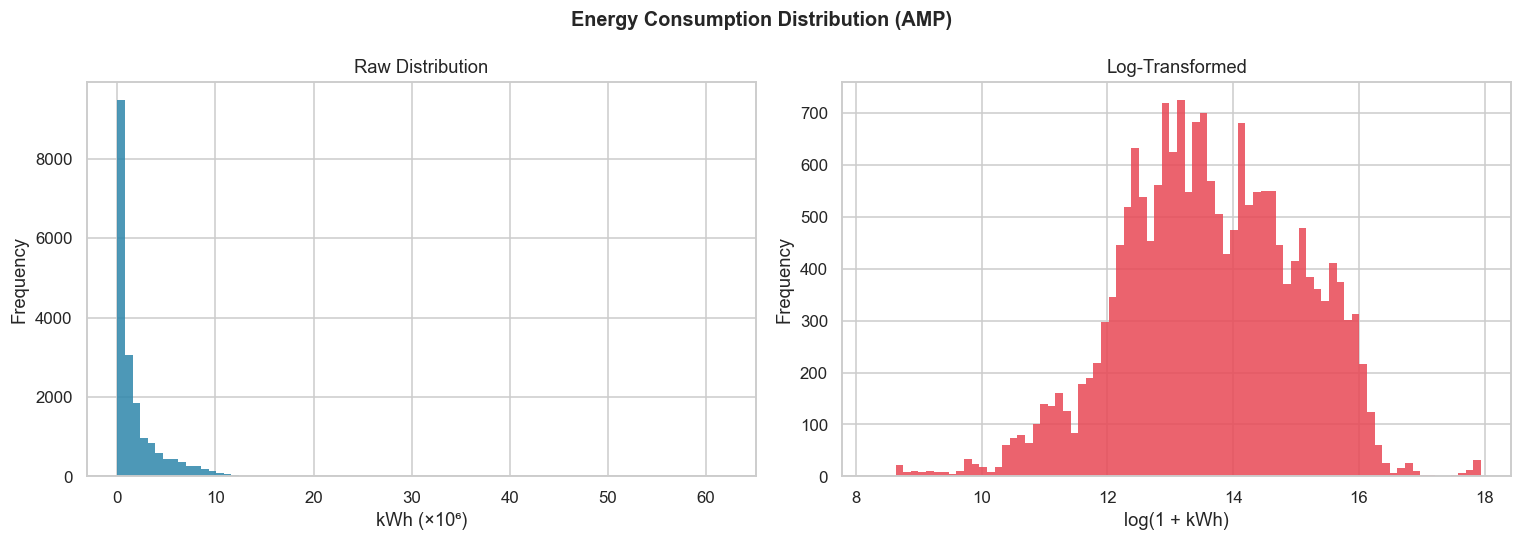

Skewness (raw): 8.39
Skewness (log): -0.18
Mean: 2,037,021 kWh
Median: 795,647 kWh
Max: 62,000,970 kWh


In [6]:
ea = consumos["Energia Ativa"].dropna()
ea_log = np.log1p(ea.clip(lower=0))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Energy Consumption Distribution (AMP)", fontsize=13, fontweight="bold")

axes[0].hist(ea/1e6, bins=80, color=ACCENT, edgecolor="none", alpha=0.85)
axes[0].set_title("Raw Distribution")
axes[0].set_xlabel("kWh (×10⁶)")
axes[0].set_ylabel("Frequency")

axes[1].hist(ea_log, bins=80, color=ACCENT2, edgecolor="none", alpha=0.85)
axes[1].set_title("Log-Transformed")
axes[1].set_xlabel("log(1 + kWh)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "01_ea_distribution.png"), dpi=110, bbox_inches="tight")
plt.show()

print(f"Skewness (raw): {stats.skew(ea):.2f}")
print(f"Skewness (log): {stats.skew(ea_log):.2f}")
print(f"Mean: {ea.mean():,.0f} kWh")
print(f"Median: {ea.median():,.0f} kWh")
print(f"Max: {ea.max():,.0f} kWh")

### 4.2 Consumption by Voltage Level

The dataset includes two voltage levels: **Baixa Tensão (BT)**: low voltage, corresponding to residential and small commercial consumers and **Muito Alta, Alta e Média Tensões (MAAT)**: high/medium voltage, corresponding to large industrial consumers. Both voltage levels are retained in the analysis; 170 of 173 parishes have BT records, so the overall distribution is dominated by BT consumption.

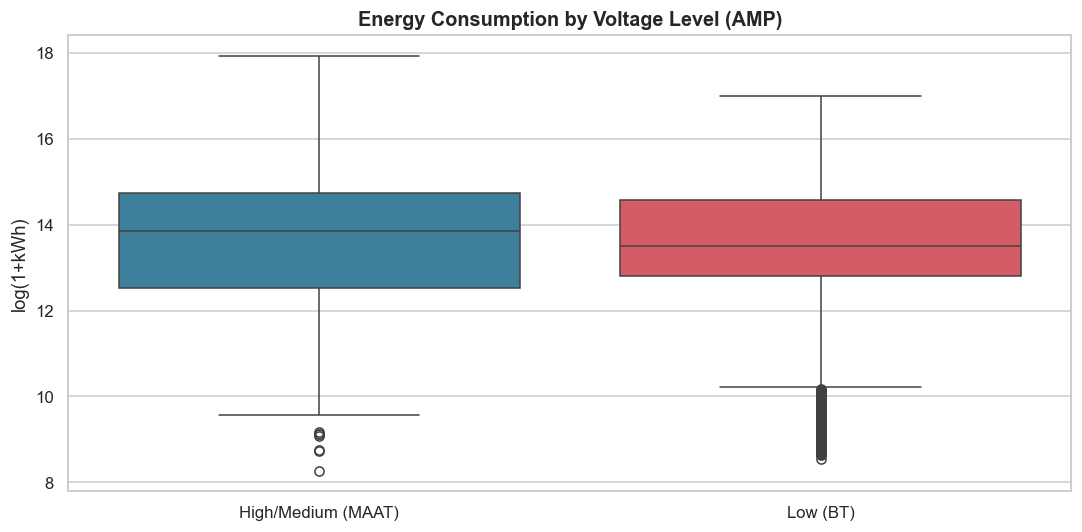

Low (BT)       : median=     727,160 kWh, n=10,194
High/Medium (MAAT): median=   1,034,812 kWh, n= 8,971


In [7]:
consumos_clean = consumos.dropna(subset=["Energia Ativa", "Voltage level"]).copy()
consumos_clean["log_EA"] = np.log1p(consumos_clean["Energia Ativa"].clip(lower=0))

fig, ax = plt.subplots(figsize=(10, 5))

vl_map = {"Baixa Tensão": "Low (BT)", "Muito Alta, Alta e Média Tensões": "High/Medium (MAAT)"}
consumos_clean["VL"] = consumos_clean["Voltage level"].map(vl_map)

sns.boxplot(data=consumos_clean, x="VL", y="log_EA", palette=[ACCENT, ACCENT2], ax=ax)
ax.set_title("Energy Consumption by Voltage Level (AMP)", fontsize=13, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("log(1+kWh)")

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "02_voltage_distribution.png"), dpi=110, bbox_inches="tight")
plt.show()

for vl in ["Baixa Tensão", "Muito Alta, Alta e Média Tensões"]:
    subset = consumos_clean[consumos_clean["Voltage level"]==vl]["Energia Ativa"]
    print(f"{vl_map[vl]:15s}: median={subset.median():>12,.0f} kWh, n={len(subset):>6,}")

### 4.3 Time-Series Decomposition

To understand the temporal structure of consumption, an additive decomposition is applied to the monthly aggregate for 2021–2024. This separates the series into trend, seasonal, and residual components, and allows us to quantify how much of the variance in consumption is explained by seasonality versus long-term drift. A strong seasonal component would support the use of monthly fixed effects or Fourier terms in the impact model.

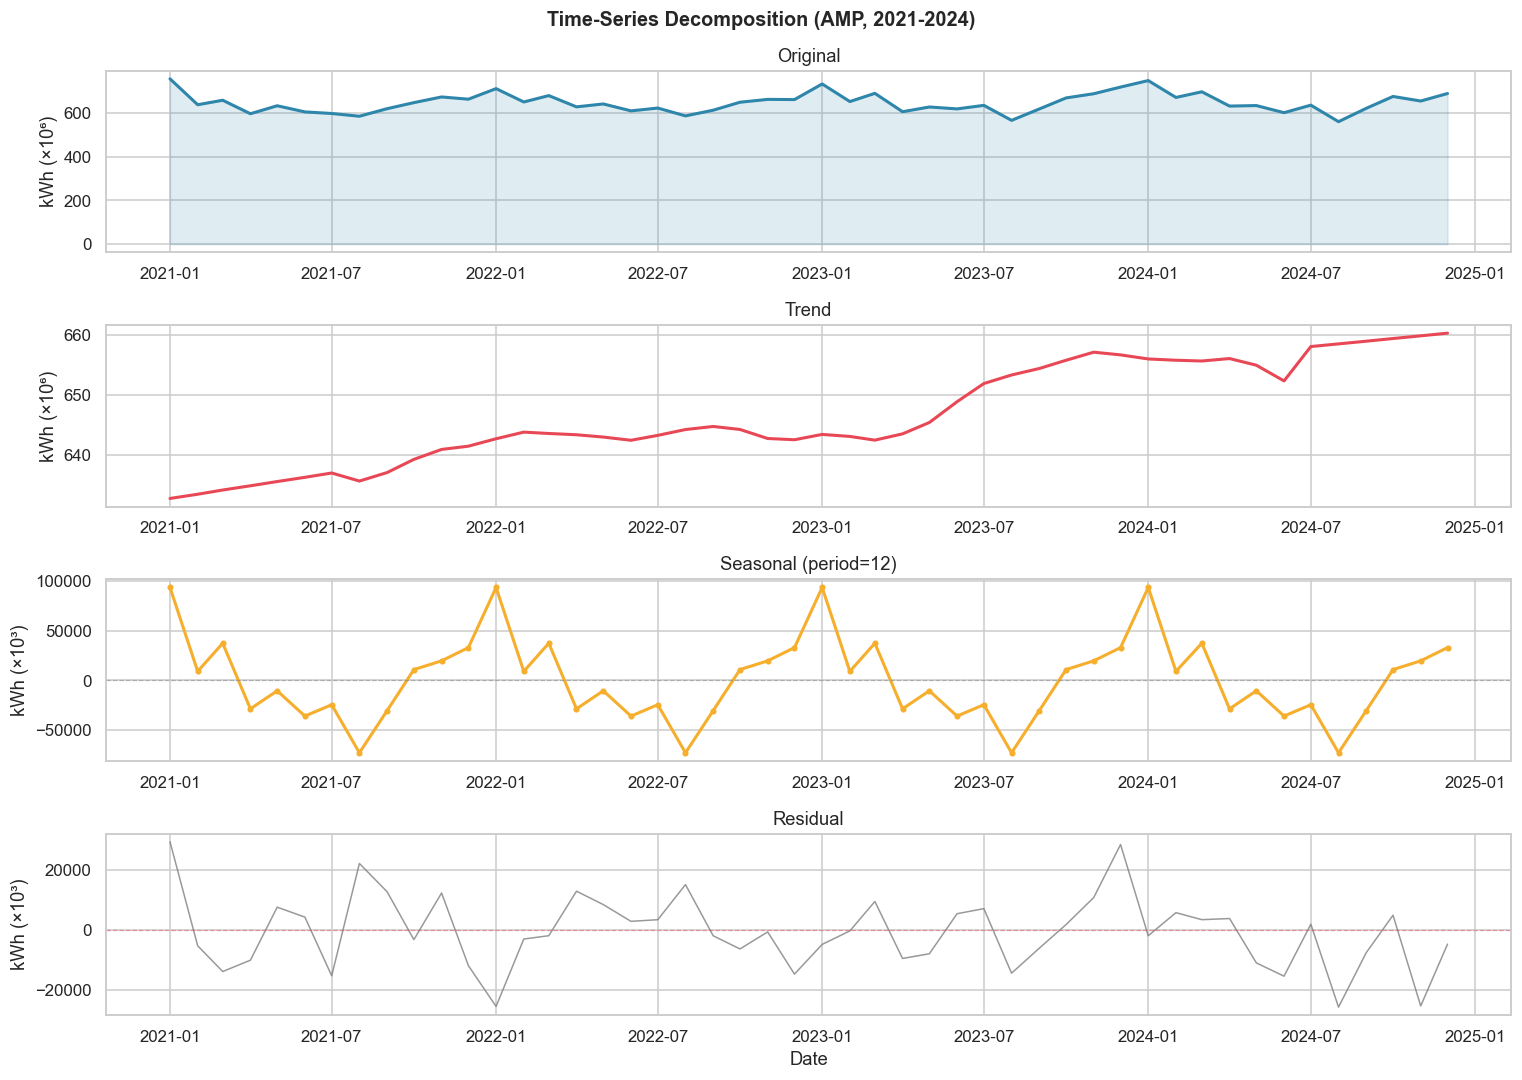

Seasonal strength: 0.9215
Trend strength: 0.1998


In [8]:
# Monthly aggregate
monthly_amp = (
    consumos
    .groupby(["Year", "Month"])["Energia Ativa"]
    .sum()
    .reset_index()
    .sort_values(["Year", "Month"])
)
monthly_amp["Date"] = pd.to_datetime(
    monthly_amp["Year"].astype(str) + "-" + monthly_amp["Month"].astype(str).str.zfill(2)
)
monthly_amp = monthly_amp.set_index("Date").sort_index()

ts_full = monthly_amp[(monthly_amp.index.year >= 2021) & (monthly_amp.index.year <= 2024)]["Energia Ativa"]

decomp = seasonal_decompose(ts_full, model="additive", period=12, extrapolate_trend="freq")

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=False)
fig.suptitle("Time-Series Decomposition (AMP, 2021-2024)", fontsize=13, fontweight="bold")

axes[0].plot(ts_full.index, ts_full.values/1e6, color=ACCENT, lw=2)
axes[0].fill_between(ts_full.index, ts_full.values/1e6, alpha=0.15, color=ACCENT)
axes[0].set_title("Original")
axes[0].set_ylabel("kWh (×10⁶)")

axes[1].plot(decomp.trend.index, decomp.trend.values/1e6, color=ACCENT2, lw=2)
axes[1].set_title("Trend")
axes[1].set_ylabel("kWh (×10⁶)")

axes[2].plot(decomp.seasonal.index, decomp.seasonal.values/1e3, color=ACCENT3, lw=2, marker="o", ms=3)
axes[2].axhline(0, color="gray", lw=0.8, linestyle="--", alpha=0.5)
axes[2].set_title("Seasonal (period=12)")
axes[2].set_ylabel("kWh (×10³)")

axes[3].plot(decomp.resid.index, decomp.resid.values/1e3, color="gray", lw=1, alpha=0.8)
axes[3].axhline(0, color=ACCENT2, lw=0.8, linestyle="--", alpha=0.5)
axes[3].set_title("Residual")
axes[3].set_ylabel("kWh (×10³)")
axes[3].set_xlabel("Date")

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "03_decomposition.png"), dpi=110, bbox_inches="tight")
plt.show()

seasonal_strength = 1 - (decomp.resid.var() / (decomp.seasonal + decomp.resid).var())
trend_strength = 1 - (decomp.resid.var() / (decomp.trend + decomp.resid).var())

print(f"Seasonal strength: {seasonal_strength:.4f}")
print(f"Trend strength: {trend_strength:.4f}")

### 4.4 Seasonality and Statistical Testing

The seasonal pattern visible in the decomposition is tested formally using a **Kruskal-Wallis H-test** across months and seasons. This non-parametric test is appropriate here because the distribution of `Energia Ativa` is non-normal, as confirmed by the skewness in section 4.1. Effect size is reported as η² (eta-squared), and the peak-to-trough amplitude is calculated to quantify the practical magnitude of seasonality.

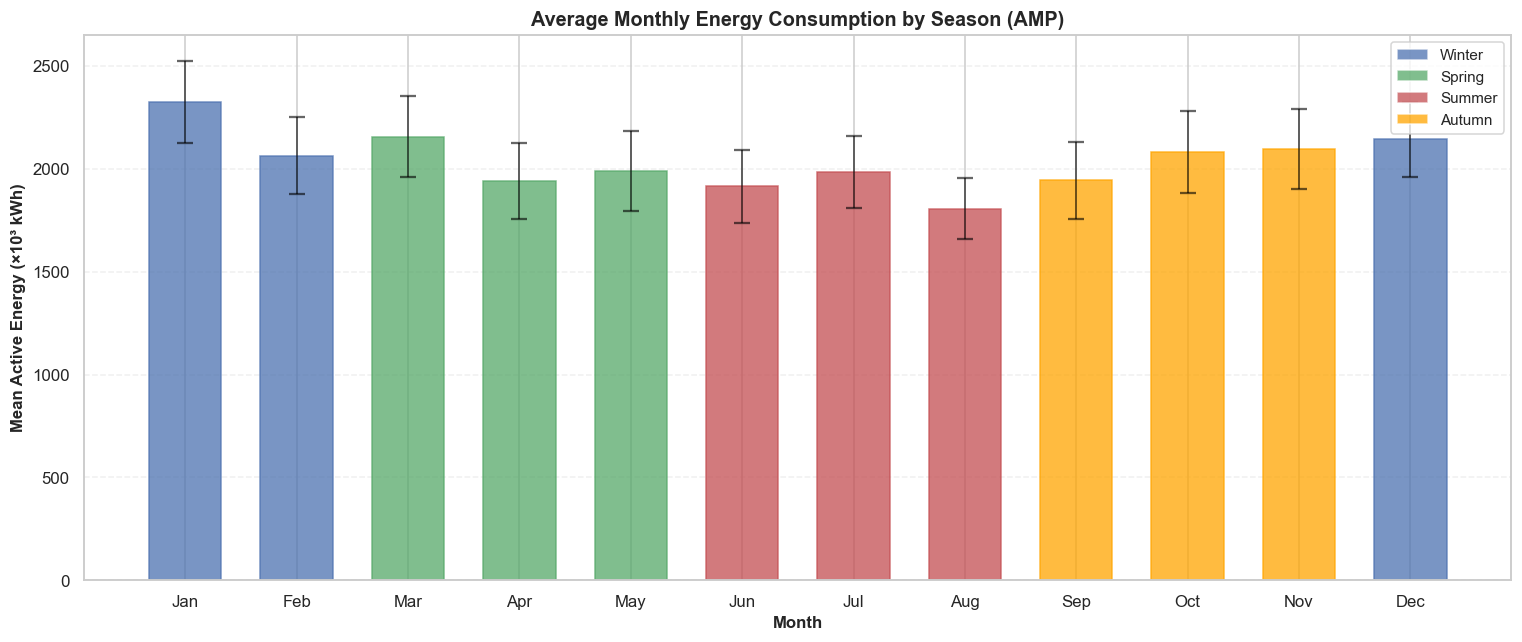

Monthly average consumption (all):
 Month Month_Name      mean       std  count
     1        Jan 2,324,764 4,085,561   1597
     2        Feb 2,064,374 3,816,247   1596
     3        Mar 2,156,203 4,011,490   1596
     4        Apr 1,940,026 3,750,611   1597
     5        May 1,990,800 3,984,064   1598
     6        Jun 1,915,339 3,621,247   1597
     7        Jul 1,984,202 3,529,540   1597
     8        Aug 1,805,264 3,015,629   1597
     9        Sep 1,944,925 3,821,273   1598
    10        Oct 2,080,829 4,075,166   1598
    11        Nov 2,095,055 3,951,919   1597
    12        Dec 2,142,624 3,707,057   1597


In [ ]:
# Monthly average across all years
consumos_all = consumos.dropna(subset=["Energia Ativa", "Month"]).copy()
monthly_avg = consumos_all.groupby("Month")["Energia Ativa"].agg(["mean", "std", "count"]).reset_index()
monthly_avg["se"] = monthly_avg["std"] / np.sqrt(monthly_avg["count"])
monthly_avg["ci_lower"] = monthly_avg["mean"] - 1.96 * monthly_avg["se"]
monthly_avg["ci_upper"] = monthly_avg["mean"] + 1.96 * monthly_avg["se"]

month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
monthly_avg["Month_Name"] = monthly_avg["Month"].map({i: month_names[i-1] for i in range(1, 13)})

# Visualization
fig, ax = plt.subplots(figsize=(14, 6))

x_pos = np.arange(len(monthly_avg))
bars = ax.bar(x_pos, monthly_avg["mean"]/1e3, color=ACCENT, edgecolor="white", alpha=0.85, width=0.65)
ax.errorbar(x_pos, monthly_avg["mean"]/1e3, 
            yerr=(monthly_avg["ci_upper"]-monthly_avg["ci_lower"])/2e3,
            fmt="none", color="black", capsize=5, capthick=1.5, alpha=0.6, lw=1.2)

# Color by season
seasons = {
    "Winter": [12, 1, 2],
    "Spring": [3, 4, 5],
    "Summer": [6, 7, 8],
    "Autumn": [9, 10, 11]
}
season_colors = {"Winter": "#4C72B0", "Spring": "#55A868", "Summer": "#C44E52", "Autumn": "#FFA500"}

for i, month in enumerate(monthly_avg["Month"].values):
    for season, months in seasons.items():
        if month in months:
            bars[i].set_color(season_colors[season])
            bars[i].set_alpha(0.75)
            break

ax.set_xlabel("Month", fontsize=11, fontweight="bold")
ax.set_ylabel("Mean Active Energy (×10³ kWh)", fontsize=11, fontweight="bold")
ax.set_title("Average Monthly Energy Consumption by Season (AMP)", fontsize=13, fontweight="bold")
ax.set_xticks(x_pos)
ax.set_xticklabels(monthly_avg["Month_Name"].values)
ax.grid(axis="y", alpha=0.3, linestyle="--")

# Add legend for seasons
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color, alpha=0.75, label=season) 
                   for season, color in season_colors.items()]
ax.legend(handles=legend_elements, loc="upper right", fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "04a_monthly_seasonality.png"), dpi=110, bbox_inches="tight")
plt.show()

print("Monthly average consumption:")
print(monthly_avg[["Month", "Month_Name", "mean", "std", "count"]].to_string(index=False,
    float_format=lambda x: f"{x:,.0f}" if x > 10 else f"{x:.2f}"))

In [10]:
# Seasonal summary
consumos_all["Season"] = consumos_all["Month"].apply(
    lambda m: "Winter" if m in [12,1,2] else ("Spring" if m in [3,4,5] 
             else ("Summer" if m in [6,7,8] else "Autumn"))
)

seasonal_stats = consumos_all.groupby("Season")["Energia Ativa"].agg([
    ("Mean (kWh)", "mean"),
    ("Median (kWh)", "median"),
    ("Std Dev (kWh)", "std"),
    ("N Obs", "count")
]).round(0).astype(int)

print("\nSeasonal summary:")
print(seasonal_stats)


Seasonal summary:
        Mean (kWh)  Median (kWh)  Std Dev (kWh)  N Obs
Season                                                
Autumn     2040258        780055        3950568   4793
Spring     2028975        777473        3917401   4791
Summer     1901602        746568        3399359   4791
Winter     2177278        883433        3873629   4790


In [11]:
# Kruskal-Wallis tests
print("\nStatistical Tests for Seasonality:")

# Monthly differences
monthly_groups = [grp["Energia Ativa"].values for _, grp in consumos_all.groupby("Month")]
kw_stat_month, kw_pval_month = kruskal(*monthly_groups)

print(f"\nKruskal-Wallis H-Test (Month):")
print(f"  H = {kw_stat_month:.4f}, p = {kw_pval_month:.2e}")
print(f"  Result: Significant difference across months (p < 0.05)")

# Seasonal differences
seasonal_groups = [grp["Energia Ativa"].values for _, grp in consumos_all.groupby("Season")]
kw_stat_season, kw_pval_season = kruskal(*seasonal_groups)

print(f"\nKruskal-Wallis H-Test (Season):")
print(f"  H = {kw_stat_season:.4f}, p = {kw_pval_season:.2e}")
print(f"  Result: Significant difference across seasons (p < 0.05)")

# Effect size
n_total = len(consumos_all)
eta_sq_month = (kw_stat_month - len(monthly_groups) + 1) / (n_total - len(monthly_groups))
eta_sq_season = (kw_stat_season - len(seasonal_groups) + 1) / (n_total - len(seasonal_groups))

print(f"\nEffect size (η²):")
print(f"  Month: {eta_sq_month:.4f}")
print(f"  Season: {eta_sq_season:.4f}")

#Coefficient of Variation by month
cv_by_month = (consumos_all.groupby("Month")["Energia Ativa"].std() / 
               consumos_all.groupby("Month")["Energia Ativa"].mean())
print(f"\nCoefficient of Variation (by month):")
print(f"  Min CV: {cv_by_month.min():.4f} (month {cv_by_month.idxmin()}: most stable)")
print(f"  Max CV: {cv_by_month.max():.4f} (month {cv_by_month.idxmax()}: most variable)")
print(f"  Mean CV: {cv_by_month.mean():.4f}")


# Seasonality amplitude
min_month = monthly_avg["mean"].idxmin()
max_month = monthly_avg["mean"].idxmax()
seasonal_amplitude = (monthly_avg["mean"].max() - monthly_avg["mean"].min()) / monthly_avg["mean"].mean()

print(f"\nSeasonality amplitude:")
print(f"  Peak: {month_names[int(monthly_avg.loc[max_month, 'Month'])-1]} ({monthly_avg.loc[max_month, 'mean']/1e3:.0f}×10³ kWh)")
print(f"  Trough: {month_names[int(monthly_avg.loc[min_month, 'Month'])-1]} ({monthly_avg.loc[min_month, 'mean']/1e3:.0f}×10³ kWh)")
print(f"  Peak-to-trough: {seasonal_amplitude:.1%}")


Statistical Tests for Seasonality:

Kruskal-Wallis H-Test (Month):
  H = 42.7775, p = 1.19e-05
  Result: Significant difference across months (p < 0.05)

Kruskal-Wallis H-Test (Season):
  H = 22.6778, p = 4.71e-05
  Result: Significant difference across seasons (p < 0.05)

Effect size (η²):
  Month: 0.0017
  Season: 0.0010

Coefficient of Variation (by month):
  Min CV: 1.6705 (month 8: most stable)
  Max CV: 2.0012 (month 5: most variable)
  Mean CV: 1.8567

Seasonality amplitude:
  Peak: Jan (2325×10³ kWh)
  Trough: Aug (1805×10³ kWh)
  Peak-to-trough: 25.5%


### 4.5 Stationarity Tests

Before any regression or difference-in-differences modelling, the consumption time series must be assessed for stationarity. A non-stationary series can produce spurious regression results. The **Augmented Dickey-Fuller (ADF)** test is applied to the level series, the first-differenced series, and the seasonally-differenced series (lag 12) to determine the order of integration.

In [12]:
print("Augmented Dickey-Fuller Test Results:")

# Level
adf_level = adfuller(ts_full.dropna(), autolag="AIC")
print(f"\nLevel series:")
print(f"  ADF stat: {adf_level[0]:.4f}, p-value: {adf_level[1]:.2e}")
print(f"  Stationary at level (p < 0.05)")

# First difference
ts_diff = ts_full.diff().dropna()
adf_diff = adfuller(ts_diff, autolag="AIC")
print(f"\nFirst-differenced series:")
print(f"  ADF stat: {adf_diff[0]:.4f}, p-value: {adf_diff[1]:.2e}")
print(f"  Stationary after first differencing (p < 0.05)")

# Seasonal difference
ts_sdiff = ts_full.diff(12).dropna()
adf_sdiff = adfuller(ts_sdiff, autolag="AIC")
print(f"\nSeasonal-differenced (lag-12):")
print(f"  ADF stat: {adf_sdiff[0]:.4f}, p-value: {adf_sdiff[1]:.2e}")
print(f"  Stationary after seasonal differencing (p < 0.05)")

Augmented Dickey-Fuller Test Results:

Level series:
  ADF stat: -4.9719, p-value: 2.52e-05
  Stationary at level (p < 0.05)

First-differenced series:
  ADF stat: -8.7214, p-value: 3.38e-14
  Stationary after first differencing (p < 0.05)

Seasonal-differenced (lag-12):
  ADF stat: -4.4246, p-value: 2.68e-04
  Stationary after seasonal differencing (p < 0.05)


### 4.6 Municipality-Level Variation

Kruskal-Wallis test (Municipality effect):
  H = 8824.70, p-value: 0.00e+00 < 0.001
  Significant heterogeneity across municipalities


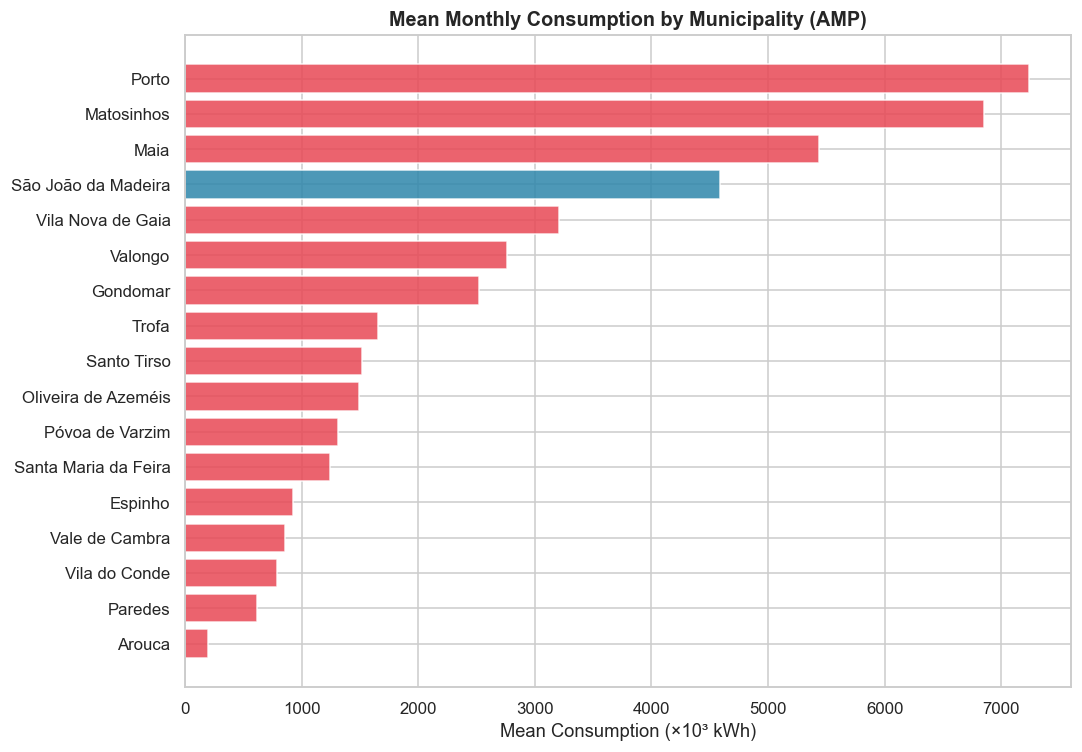

In [13]:
# Test for municipality differences
amp_mun_groups = [
    grp["Energia Ativa"].dropna().values
    for _, grp in consumos.groupby("Municipality")
    if grp["Energia Ativa"].dropna().shape[0] > 10
]

kw_stat, kw_pval = kruskal(*amp_mun_groups)
print(f"Kruskal-Wallis test (Municipality effect):")
print(f"  H = {kw_stat:.2f}, p-value: {kw_pval:.2e} < 0.001")
print(f"  Significant heterogeneity across municipalities")

# Plot mean consumption by municipality
mun_mean = (
    consumos
    .groupby("Municipality")["Energia Ativa"]
    .mean()
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 7))
colors = [ACCENT2 if m in comunidades["Municipality"].values else ACCENT for m in mun_mean.index]
ax.barh(mun_mean.index, mun_mean.values/1e3, color=colors, edgecolor="white", alpha=0.85)
ax.set_title("Mean Monthly Consumption by Municipality (AMP)", fontsize=13, fontweight="bold")
ax.set_xlabel("Mean Consumption (×10³ kWh)")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "05_mun_consumption.png"), dpi=110, bbox_inches="tight")
plt.show()

### 4.7 Treatment vs. Control

A key concern for impact evaluation is **selection bias**: if treatment parishes differ systematically from control parishes in their baseline consumption, a simple before/after comparison would be confounded. This section compares the consumption distributions of treatment and control parishes in 2023–2024 using a Mann-Whitney U test. Any significant difference must be accounted for in the modelling stage, for example through matching, weighting, or a difference-in-differences design with parish-level fixed effects.

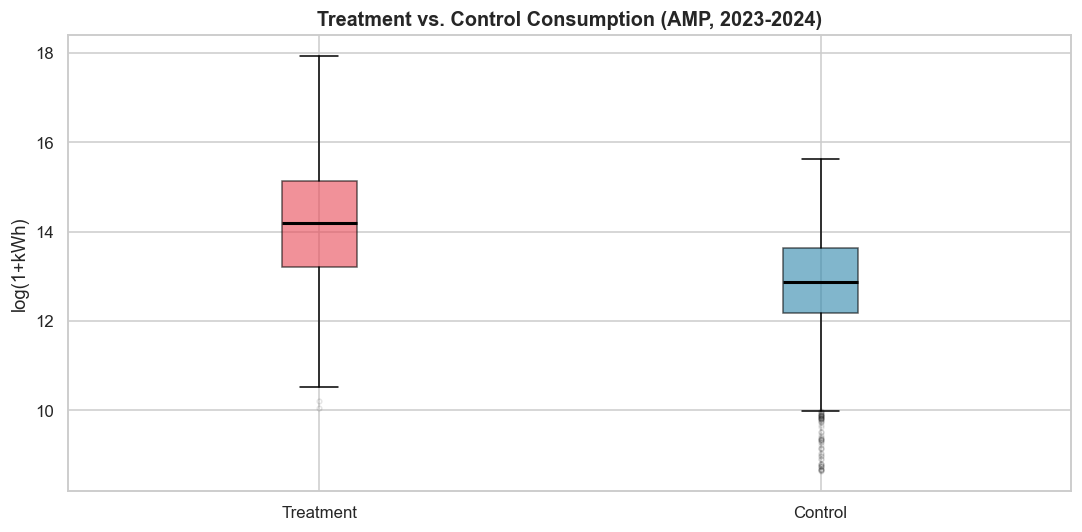

Mann-Whitney U test (Treatment vs. Control):
  p-value: 0.00e+00
  Treatment median: 1,458,297 kWh
  Control median: 391,252 kWh
  Ratio (T/C): 3.73
  Note: Significant selection bias (treatment parishes consume more)


In [14]:
consumos["in_treatment"] = consumos["DistrictMunicipalityParishCode"].astype(str).isin(
    set(comunidades["Parish Code"].astype(str).unique())
)

treat_vals = consumos[
    (consumos["in_treatment"]) &
    (consumos["Year"].isin([2023,2024]))
]["Energia Ativa"].dropna()

ctrl_vals = consumos[
    (~consumos["in_treatment"]) &
    (consumos["Year"].isin([2023,2024]))
]["Energia Ativa"].dropna()

fig, ax = plt.subplots(figsize=(10, 5))

bp = ax.boxplot(
    [np.log1p(treat_vals.clip(lower=0)), np.log1p(ctrl_vals.clip(lower=0))],
    labels=["Treatment", "Control"],
    patch_artist=True,
    boxprops=dict(facecolor=ACCENT, alpha=0.6),
    medianprops=dict(color="black", lw=2),
    flierprops=dict(marker=".", alpha=0.1)
)

bp["boxes"][0].set_facecolor(ACCENT2)
bp["boxes"][0].set_alpha(0.6)

ax.set_title("Treatment vs. Control Consumption (AMP, 2023-2024)", fontsize=13, fontweight="bold")
ax.set_ylabel("log(1+kWh)")

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "06_treatment_control.png"), dpi=110, bbox_inches="tight")
plt.show()

mw_stat, mw_pval = mannwhitneyu(treat_vals, ctrl_vals, alternative="two-sided")

print(f"Mann-Whitney U test (Treatment vs. Control):")
print(f"  p-value: {mw_pval:.2e}")
print(f"  Treatment median: {treat_vals.median():,.0f} kWh")
print(f"  Control median: {ctrl_vals.median():,.0f} kWh")
print(f"  Ratio (T/C): {treat_vals.median()/ctrl_vals.median():.2f}")
print(f"  Note: Significant selection bias (treatment parishes consume more)")

### 4.8 Energy Communities Distribution

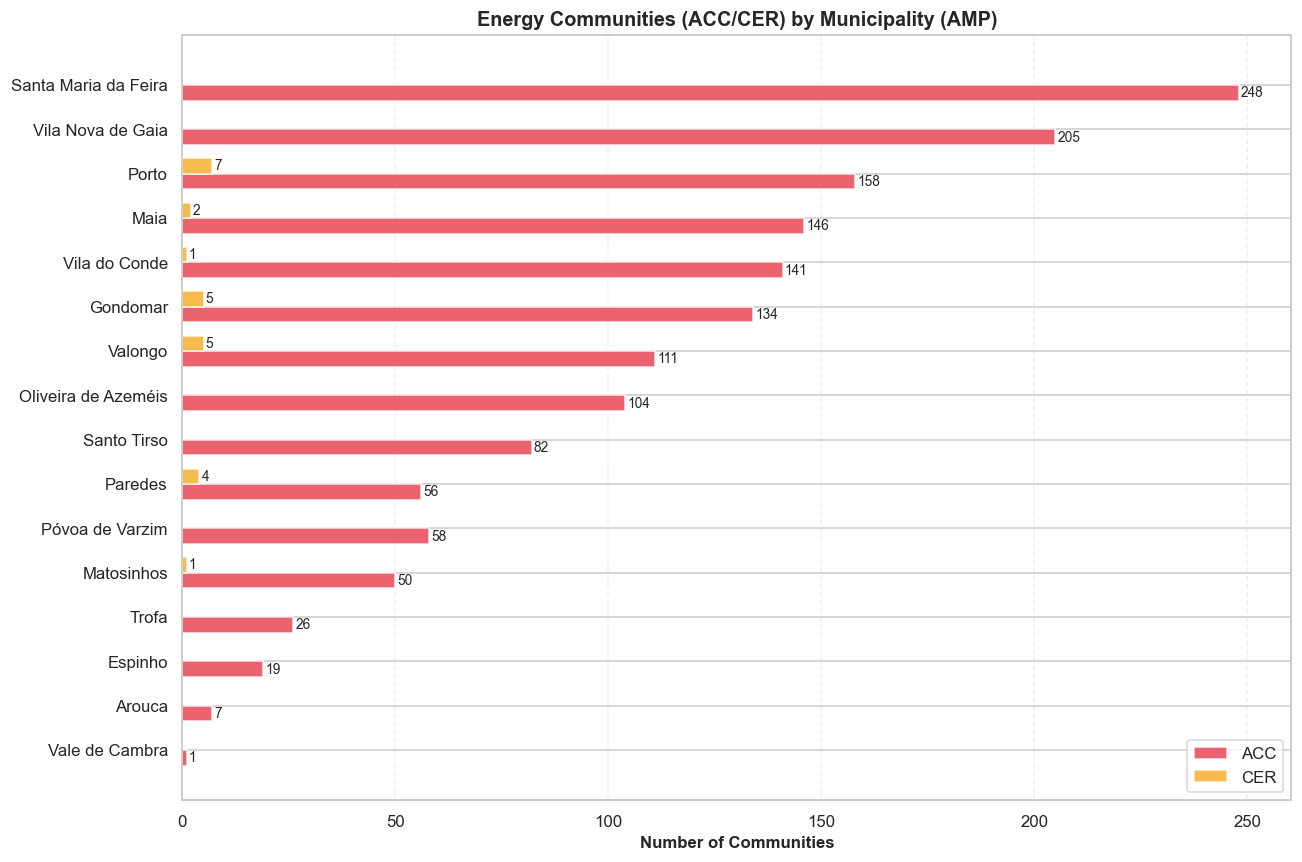


Energy communities by municipality:
Type ACC/CER          ACC  CER  Total
Municipality                         
Vale de Cambra          1    0      1
Arouca                  7    0      7
Espinho                19    0     19
Trofa                  26    0     26
Matosinhos             50    1     51
Póvoa de Varzim        58    0     58
Paredes                56    4     60
Santo Tirso            82    0     82
Oliveira de Azeméis   104    0    104
Valongo               111    5    116
Gondomar              134    5    139
Vila do Conde         141    1    142
Maia                  146    2    148
Porto                 158    7    165
Vila Nova de Gaia     205    0    205
Santa Maria da Feira  248    0    248

ACC Communities:
  Total ACC:          1,546
  Municipalities:     16
  Mean per mun.:      96.6
  Median per mun.:    93
  Max:                248 (Santa Maria da Feira)

CER Communities:
  Total CER:          25
  Municipalities:     7
  Mean per mun.:      1.6
  Median per m

In [15]:
# Distribution of ACC/CER communities by municipality
com_by_mun = comunidades.groupby(["Municipality", "Type ACC/CER"])["ACC_CER_Count"].sum().unstack(fill_value=0)
com_by_mun["Total"] = com_by_mun.sum(axis=1)
com_by_mun = com_by_mun.sort_values("Total", ascending=True)

# Create grouped bar chart
fig, ax = plt.subplots(figsize=(12, 8))

x = np.arange(len(com_by_mun))
width = 0.35

# Check if both ACC and CER exist
if "ACC" in com_by_mun.columns:
    acc_bars = ax.barh(x - width/2, com_by_mun["ACC"], width, label="ACC", color=ACCENT2, alpha=0.85, edgecolor="white")
if "CER" in com_by_mun.columns:
    cer_bars = ax.barh(x + width/2, com_by_mun["CER"], width, label="CER", color=ACCENT3, alpha=0.85, edgecolor="white")

ax.set_yticks(x)
ax.set_yticklabels(com_by_mun.index)
ax.set_xlabel("Number of Communities", fontsize=11, fontweight="bold")
ax.set_title("Energy Communities (ACC/CER) by Municipality (AMP)", fontsize=13, fontweight="bold")
ax.legend(fontsize=11, loc="lower right")
ax.grid(axis="x", alpha=0.3, linestyle="--")

for bars in [acc_bars, cer_bars]:
    for bar in bars:
        width_val = bar.get_width()
        if width_val > 0:
            ax.text(width_val + 0.5, bar.get_y() + bar.get_height()/2, 
                   f'{int(width_val)}', ha='left', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "08_acc_cer_by_municipality.png"), dpi=110, bbox_inches="tight")
plt.show()

print("\nEnergy communities by municipality:")
print(com_by_mun.to_string())

if "ACC" in com_by_mun.columns:
    print(f"\nACC Communities:")
    print(f"  Total ACC:          {int(com_by_mun['ACC'].sum()):,}")
    print(f"  Municipalities:     {(com_by_mun['ACC'] > 0).sum()}")
    print(f"  Mean per mun.:      {com_by_mun['ACC'].mean():.1f}")
    print(f"  Median per mun.:    {com_by_mun['ACC'].median():.0f}")
    print(f"  Max:                {int(com_by_mun['ACC'].max())} ({com_by_mun['ACC'].idxmax()})")

if "CER" in com_by_mun.columns:
    print(f"\nCER Communities:")
    print(f"  Total CER:          {int(com_by_mun['CER'].sum()):,}")
    print(f"  Municipalities:     {(com_by_mun['CER'] > 0).sum()}")
    print(f"  Mean per mun.:      {com_by_mun['CER'].mean():.1f}")
    print(f"  Median per mun.:    {com_by_mun['CER'].median():.0f}")
    print(f"  Max:                {int(com_by_mun['CER'].max())} ({com_by_mun['CER'].idxmax()})")

print(f"Total communities: {int(com_by_mun['Total'].sum()):,}")

### 4.9 Community Growth Over Time

The growth charts show that ACC communities far outnumber CER communities in AMP, and that registrations have been increasing over the study period. This staggered adoption pattern means the treatment is not a single event but a rolling one. This is a consideration for the modelling strategy, for example using treatment entry date rather than a single binary indicator.

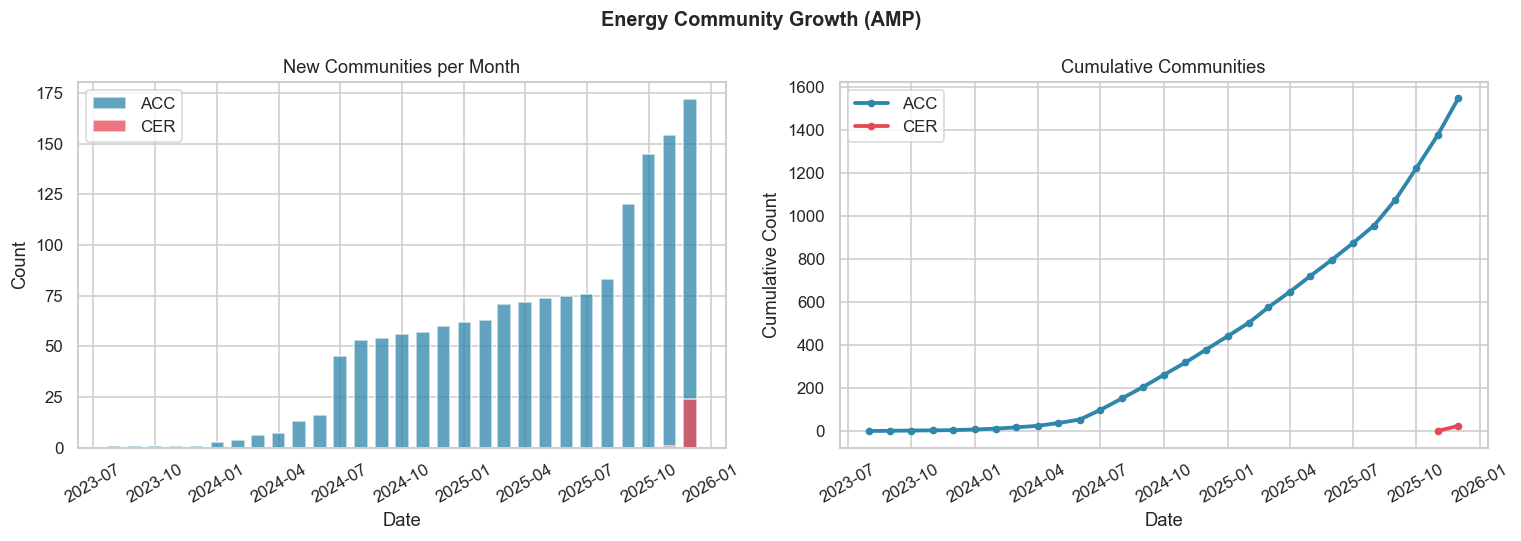

ACC total: 1,546
CER total: 25
Ratio ACC/CER: 62:1


In [16]:
com_monthly = (
    comunidades.groupby(["Year", "Month", "Type ACC/CER"])["ACC_CER_Count"]
    .sum()
    .reset_index()
)
com_monthly["Date"] = pd.to_datetime(
    com_monthly["Year"].astype(str) + "-" + com_monthly["Month"].astype(str).str.zfill(2)
)

com_cum = (
    comunidades.groupby(["Date", "Type ACC/CER"])["ACC_CER_Count"]
    .sum()
    .groupby(level="Type ACC/CER")
    .cumsum()
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Energy Community Growth (AMP)", fontsize=13, fontweight="bold")

# Monthly new registrations
for typ, col in zip(["ACC", "CER"], [ACCENT, ACCENT2]):
    sub = com_monthly[com_monthly["Type ACC/CER"]==typ].sort_values("Date")
    axes[0].bar(sub["Date"], sub["ACC_CER_Count"], label=typ, alpha=0.75, color=col, width=20)
axes[0].set_title("New Communities per Month")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Count")
axes[0].legend()
axes[0].tick_params(axis="x", rotation=30)

# Cumulative
for typ, col in zip(["ACC", "CER"], [ACCENT, ACCENT2]):
    sub = com_cum[com_cum["Type ACC/CER"]==typ].sort_values("Date")
    axes[1].plot(sub["Date"], sub["ACC_CER_Count"], lw=2.5, label=typ, color=col, marker="o", ms=4)
axes[1].set_title("Cumulative Communities")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Cumulative Count")
axes[1].legend()
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "07_community_growth.png"), dpi=110, bbox_inches="tight")
plt.show()

acc_total = comunidades[comunidades["Type ACC/CER"]=="ACC"]["ACC_CER_Count"].sum()
cer_total = comunidades[comunidades["Type ACC/CER"]=="CER"]["ACC_CER_Count"].sum()

print(f"ACC total: {int(acc_total):,}")
print(f"CER total: {int(cer_total)}")
print(f"Ratio ACC/CER: {acc_total/max(cer_total,1):.0f}:1")

## 5. Data Quality Assessment

### 5.1 Missing Values

In [17]:
print("Missing values:")
print(f"  consumos: {consumos.isnull().sum().sum()} total")
print(f"  comunidades: {comunidades.isnull().sum().sum()} total")
print(f"  No missing data in either dataset")

Missing values:
  consumos: 0 total
  comunidades: 0 total
  No missing data in either dataset


### 5.2 Outliers and Data Issues

In [18]:
# Negative values
neg_vals = consumos[consumos["Energia Ativa"] < 0]
print(f"Negative Energia Ativa records: {len(neg_vals):,}")
if len(neg_vals) > 0:
    print(f"  Mostly OUTROS-Porto records (no parish assigned)")
    print(f"  Recommendation: Exclude from analysis")

# Outliers
ea_bt = consumos["Energia Ativa"].dropna()
Q1, Q3 = ea_bt.quantile(0.25), ea_bt.quantile(0.75)
IQR = Q3 - Q1
upper_fence = Q3 + 3.0 * IQR
outliers = len(consumos[consumos["Energia Ativa"] > upper_fence])

print(f"\nOutliers (IQR × 3): {outliers:,} ({outliers/len(consumos)*100:.2f}%)")
print(f"  Minor outlier population, acceptable for analysis")

Negative Energia Ativa records: 0

Outliers (IQR × 3): 710 (3.70%)
  Minor outlier population, acceptable for analysis


### 5.3 Panel Completeness

In [21]:
parish_coverage = (
    consumos
    .groupby("DistrictMunicipalityParishCode")["Date"]
    .nunique()
    .reset_index()
    .rename(columns={"Date": "n_months"})
)

max_months = consumos["Date"].nunique()
parish_coverage["completeness_pct"] = parish_coverage["n_months"] / max_months * 100

print(f"Panel completeness (all parishes):")
print(f"  Max possible months: {max_months}")
print(f"  Parishes ≥80% complete: {(parish_coverage['completeness_pct']>=80).sum()}")
print(f"  Parishes ≥48 months: {(parish_coverage['n_months']>=48).sum()}")
print(f"  Mean completeness: {parish_coverage['completeness_pct'].mean():.1f}%")

Panel completeness (all parishes):
  Max possible months: 60
  Parishes ≥80% complete: 173
  Parishes ≥48 months: 173
  Mean completeness: 100.0%


## 6. Key Findings and Conclusions

### Data Quality
- No missing values in either dataset
- Panel completeness is high across all parishes 
- Outliers below 4% of records;
- Both datasets are **suitable for impact modelling** with minor preprocessing

### Temporal Patterns
- Strong seasonality, with a peak-to-trough between winter and summer months
- Moderate upward trend across 2021–2024
- The series is stationary at level, with strong deterministic seasonality, supporting a log-transformed panel model with month fixed effects.

### Spatial Variation
- Significant heterogeneity across municipalities (Kruskal–Wallis test, p < 0.001) supports the inclusion of municipality fixed effects
- Treatment parishes consume substantially more than control parishes, confirming selection bias that should be addressed in the modelling design